In [8]:
import numpy as np
import numpy as np
import torch
import sys, os
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
from datasets.data import SpatialDataset
from datasets.transformerRegressorDataClass import TransformerPointDataset, collate_point_batches
from torch.utils.data import DataLoader
#from datasets.dt2_data import load_dt2_data
from models.transformerRegressor import TransformerCLSRegressor
import numpy as np
import matplotlib.pyplot as plt
from Transformer_Map_Interp.argument_transformer import parse_opt

/home/user_116/Project-B-Technion


In [6]:
@torch.no_grad()
def evaluate_split(model, dataset, trainset, device):
    ds = TransformerPointDataset(dataset, trainset, device=device)
    loader = DataLoader(ds, batch_size=32, shuffle=False, collate_fn=collate_point_batches)

    preds, trues, coords = [], [], []
    y_mean, y_std = trainset.y_mean.to(device), trainset.y_std.to(device)

    model.eval()
    for mem, mask, y, cls_coord in loader:
        mem, mask, y = mem.to(device), mask.to(device), y.to(device)
        y_hat = model(mem, mask)

        # denormalize
        y_hat_real = y_hat * y_std + y_mean
        y_real = y * y_std + y_mean

        preds.append(y_hat_real.cpu())
        trues.append(y_real.cpu())
        coords.append(cls_coord.cpu())

    preds = torch.cat(preds)
    trues = torch.cat(trues)
    coords = torch.cat(coords)

    abs_err = torch.abs(preds - trues)
    rel_err = abs_err / (torch.abs(trues) + 1e-6)
    return coords, abs_err, rel_err


def plot_error_map(coords, errors, title="Error map", cmap="inferno"):
    plt.figure(figsize=(10,8))
    sc = plt.scatter(coords[:,1], coords[:,0], c=errors, s=6, cmap=cmap)
    plt.colorbar(sc, label="Absolute Error (m)")
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.title(title)
    plt.show()

In [7]:
# Show the current working directory
from pathlib import Path
print(os.getcwd())
os.chdir("..")
sys.path.append(os.path.abspath(".."))  # project root
print(os.path.abspath(".."))
p_cache = Path("cache")
print("cache exists?", p_cache.exists(), "->", p_cache.resolve())
trainset = torch.load(r"./cache/trainset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.001_seed5.pt",map_location="cpu",weights_only=False)
validset = torch.load(r"./cache/validset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.001_seed5.pt",map_location="cpu",weights_only=False)
testset = torch.load(r"./cache/testset_n32_e035_1arc_v3_cropped_train_n32_e035_1arc_v3_cropped_val_n32_e035_1arc_v3_cropped_test_keep_n0.001_seed5.pt",map_location="cpu",weights_only=False)

/home/user_116/Project-B-Technion/Transformer_Map_Interp/display
/home/user_116/Project-B-Technion
cache exists? True -> /home/user_116/Project-B-Technion/Transformer_Map_Interp/cache


In [26]:
import argparse
import torch
argv_bak = sys.argv
try:
    sys.argv = [argv_bak[0]]  # keep program name only; drop Jupyter’s flags
    args = parse_opt()
finally:
    sys.argv = argv_bak
args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args.dropout = 0.0
args.model = "transformer"
in_dim = 3  # [Δlat, Δlon, y_known_norm, is_observed] # Orit 12.10 from 4 --> 3
print("Using device:", args.device)
model = TransformerCLSRegressor(
    in_dim=in_dim,
    d_model=args.d_model,
    nhead=args.n_heads,       # keep your arg names as-is
    num_layers=args.n_layers, # keep your arg names as-is
    dim_feedforward=args.ffn_dim,
    dropout=args.dropout,
    #cls_init=args.cls_init,
    use_posenc=args.use_posenc,
).to(args.device)
print("Model initialized:")
print(model)
sys.path.append(os.path.abspath("../"))  # project root
print(os.path.abspath("../"))
print("Current working directory:", os.getcwd())
print("File exists?", os.path.exists("../saved_models/Exp_3/Final_Train/best_model_27.pt"))
ckpt_path = f"../saved_models/Exp_3/Final_Train/best_model_27.pt"
last_path = f"../saved_models/Exp_3/Final_Train/last_epoch_model.pt"
print(f"Loading checkpoint from {ckpt_path}")
model.load_state_dict(torch.load(ckpt_path, map_location=args.device))

device: cuda
Using device: cuda
Model initialized:
TransformerCLSRegressor(
  (in_proj): Linear(in_features=3, out_features=256, bias=True)
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=256, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=Fal

<All keys matched successfully>

Validation mean abs error: 13.96 m | mean rel error: 4114.642


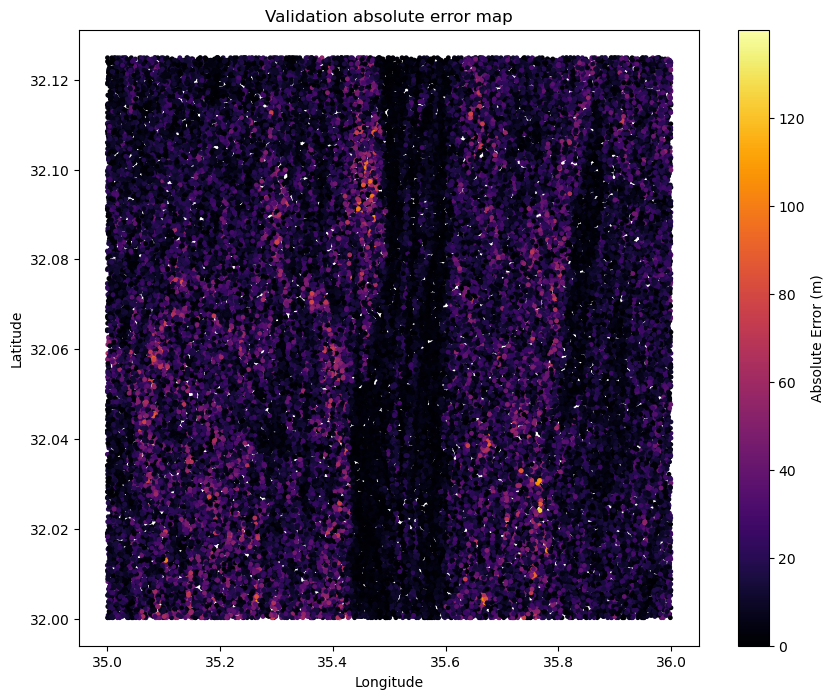

Test mean abs error: 8.51 m | mean rel error: 83690.891


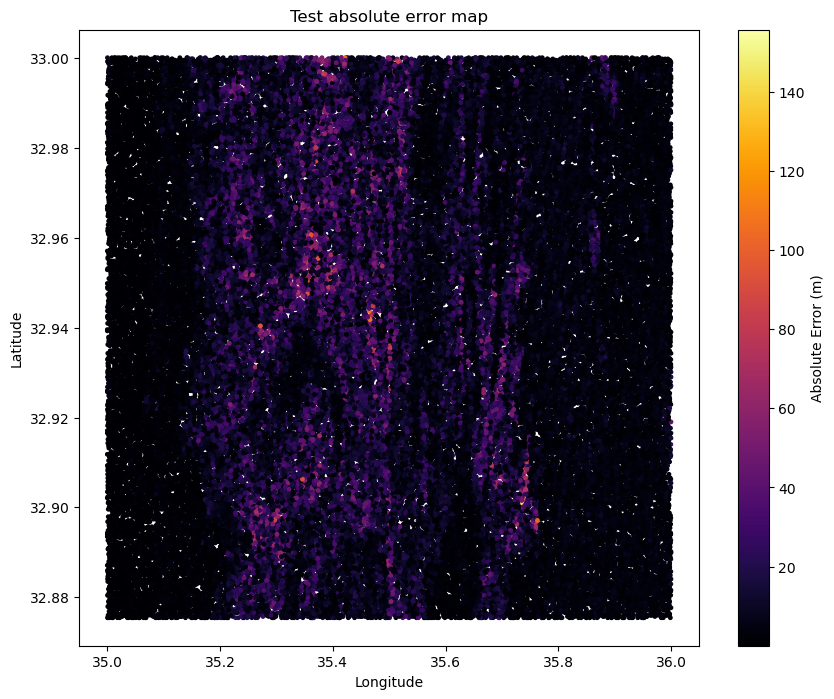

In [28]:
 # Evaluate and visualize
for name, dataset in [("Validation", validset), ("Test", testset)]:
    coords, abs_err, rel_err = evaluate_split(model, dataset, trainset, args.device)
    print(f"{name} mean abs error: {abs_err.mean():.2f} m | mean rel error: {rel_err.mean():.3f}")
    plot_error_map(coords, abs_err, title=f"{name} absolute error map")

In [29]:
@torch.no_grad()
def evaluate_split(model, dataset, trainset, device):
    ds = TransformerPointDataset(dataset, trainset, device=device)
    loader = DataLoader(ds, batch_size=32, shuffle=False, collate_fn=collate_point_batches)
    preds, trues, coords = [], [], []
    y_mean, y_std = trainset.y_mean.to(device), trainset.y_std.to(device)

    model.eval()
    for mem, mask, y, cls_coord in loader:
        mem, mask, y = mem.to(device), mask.to(device), y.to(device)
        y_hat = model(mem, mask)
        y_hat_real = y_hat * y_std + y_mean
        y_real = y * y_std + y_mean
        preds.append(y_hat_real.cpu())
        trues.append(y_real.cpu())
        coords.append(cls_coord.cpu())

    preds = torch.cat(preds)
    trues = torch.cat(trues)
    coords = torch.cat(coords)
    abs_err = torch.abs(preds - trues)
    return coords, abs_err


def plot_error_overlay(dt2_path, val_coords, val_err, test_coords, test_err, title="Model error overlay"):
    """Show DTED background with val/test error scatter"""
    with rasterio.open(dt2_path) as src:
        elev = src.read(1)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    plt.figure(figsize=(10, 8))
    plt.imshow(elev, extent=extent, origin="upper", cmap="terrain")
    plt.colorbar(label="Elevation (m)", fraction=0.046, pad=0.04)
    sc1 = plt.scatter(val_coords[:,1], val_coords[:,0], c=val_err, s=15, cmap="viridis", label="Validation")
    sc2 = plt.scatter(test_coords[:,1], test_coords[:,0], c=test_err, s=15, cmap="inferno", label="Test", marker='x')

    cbar = plt.colorbar(sc2, label="Absolute Error (m)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.legend()
    plt.show()


In [ ]:
    # 3. Evaluate on val/test
    val_coords, val_err = evaluate_split(model, validset, trainset, args.device)
    test_coords, test_err = evaluate_split(model, testset, trainset, args.device)
    print(f"Validation mean abs error: {val_err.mean():.2f} m")
    print(f"Test mean abs error: {test_err.mean():.2f} m")

    # 4. Plot overlay on original DTED map
    dt2_path = os.path.join(args.data_path, args.dataset + ".tiff")
    plot_error_overlay(dt2_path, val_coords, val_err, test_coords, test_err,
                       title=f"Spatial error overlay ({args.dataset})")